
🔍 Analyzing: drive_test_058.avi


d:\Users\Anoshia\BattingEdge_FYP\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Frames extracted: 14
Biomech shape: (14, 4)
Mean biomech values:
  Wrist velocity: 0.1354
  Knee angle:     90.00°
  Bat angle:      44.35°
  Stance width:   0.0982


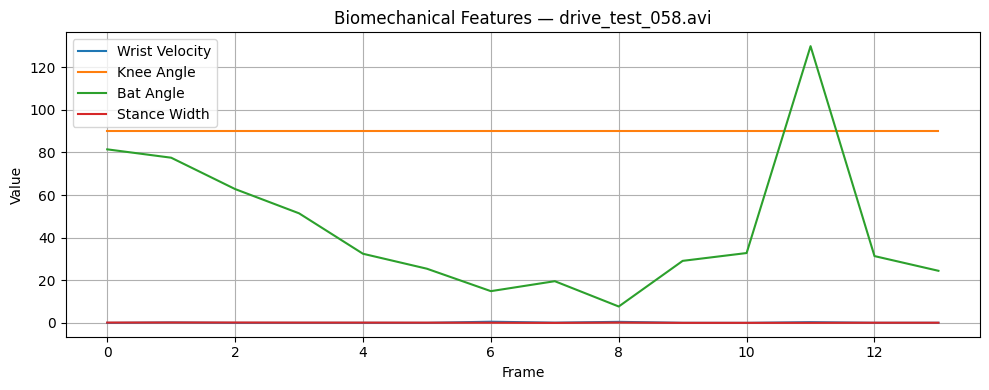


🔍 Analyzing: pull_test_031.avi
✅ Frames extracted: 35
Biomech shape: (35, 4)
Mean biomech values:
  Wrist velocity: 0.0675
  Knee angle:     90.00°
  Bat angle:      35.34°
  Stance width:   0.0653


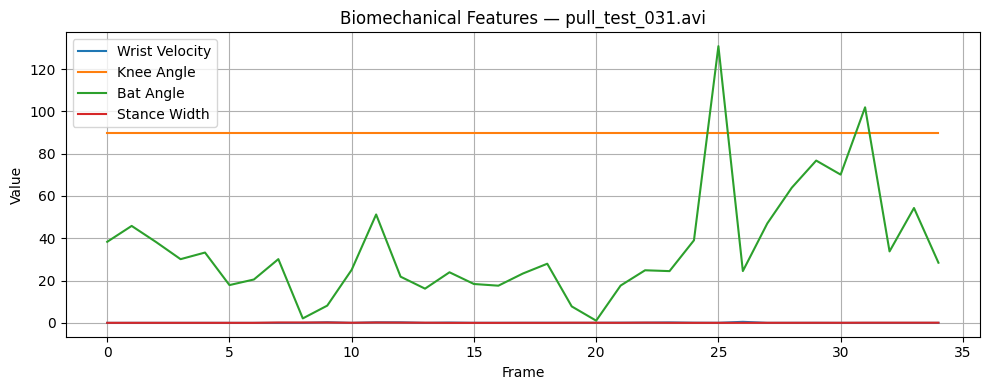


🔍 Analyzing: drive_test_020.avi
✅ Frames extracted: 24
Biomech shape: (24, 4)
Mean biomech values:
  Wrist velocity: 0.0843
  Knee angle:     90.00°
  Bat angle:      33.84°
  Stance width:   0.0399


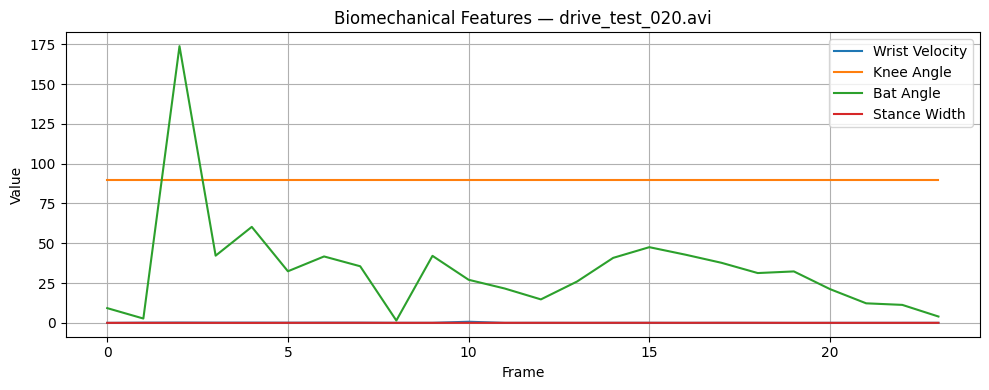

In [1]:
# Step 5: Diagnostics — Compare Pose & Biomech Features
# Run from BattingEdge_FYP/notebooks

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import mediapipe as mp
from sklearn.preprocessing import StandardScaler
import joblib

# Paths
ROOT = Path("..")
VIDEO_DIR = ROOT / "data" / "dataset_v7_clean" / "test"
SCALER_PATH = ROOT / "backend" / "models" / "shot_scaler_V8p.pkl"

# MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=2,
                    enable_segmentation=False, min_detection_confidence=0.55,
                    min_tracking_confidence=0.55)

# Landmark indices
LW, RW = 15, 16
LS, RS = 11, 12
LK, RK = 25, 26
LA, RA = 27, 28

def extract_features(video_path):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    biomech = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if not res.pose_landmarks: continue
        lms = res.pose_landmarks.landmark
        vec = [lm.x for lm in lms] + [lm.y for lm in lms] + [lm.z for lm in lms]
        frames.append(vec)

        lw = (lms[LW].x, lms[LW].y); rw = (lms[RW].x, lms[RW].y)
        ls = (lms[LS].x, lms[LS].y); rs = (lms[RS].x, lms[RS].y)
        lk = (lms[LK].x, lms[LK].y); la = (lms[LA].x, lms[LA].y)
        ra = (lms[RA].x, lms[RA].y)

        # Wrist velocity
        if len(biomech) > 0:
            prev = biomech[-1]
            v_l = np.linalg.norm(np.array(lw) - np.array(prev[0]))
            v_r = np.linalg.norm(np.array(rw) - np.array(prev[1]))
            wrist_vel = max(v_l, v_r)
        else:
            wrist_vel = 0.0

        # Knee angle
        def angle_deg(a, b, c):
            v1 = np.array([a[0]-b[0], a[1]-b[1]])
            v2 = np.array([c[0]-b[0], c[1]-b[1]])
            n1 = np.linalg.norm(v1)+1e-6; n2 = np.linalg.norm(v2)+1e-6
            cosang = np.clip(np.dot(v1, v2)/(n1*n2), -1.0, 1.0)
            return np.degrees(np.arccos(cosang))
        knee_angle = angle_deg(lk, lk, la)

        # Bat angle
        def bat_angle_deg(lw, rw, ls, rs):
            v1 = np.array([rw[0]-lw[0], rw[1]-lw[1]])
            v2 = np.array([rs[0]-ls[0], rs[1]-ls[1]])
            n1 = np.linalg.norm(v1)+1e-6; n2 = np.linalg.norm(v2)+1e-6
            cosang = np.clip(np.dot(v1, v2)/(n1*n2), -1.0, 1.0)
            return np.degrees(np.arccos(cosang))
        bat_angle = bat_angle_deg(lw, rw, ls, rs)

        # Stance width
        stance = np.linalg.norm(np.array(ra) - np.array(la))

        biomech.append([lw, rw, wrist_vel, knee_angle, bat_angle, stance])
    cap.release()

    if len(frames) == 0:
        return None, None

    X = np.array(frames, dtype=np.float32)
    B = np.array([[b[2], b[3], b[4], b[5]] for b in biomech], dtype=np.float32)
    return X, B

def plot_biomech(biomech, title):
    plt.figure(figsize=(10, 4))
    labels = ["Wrist Velocity", "Knee Angle", "Bat Angle", "Stance Width"]
    for i in range(4):
        plt.plot(biomech[:, i], label=labels[i])
    plt.title(f"Biomechanical Features — {title}")
    plt.xlabel("Frame")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Run diagnostics on selected videos ===
# Replace with actual filenames from your test set
video_paths = [
    VIDEO_DIR / "drive" / "drive_test_058.avi",
    VIDEO_DIR / "pull" / "pull_test_031.avi",
    VIDEO_DIR / "drive" / "drive_test_020.avi"
]

for vp in video_paths:
    print(f"\n🔍 Analyzing: {vp.name}")
    X, B = extract_features(vp)
    if X is None:
        print("❌ No valid pose frames found.")
        continue
    print(f"✅ Frames extracted: {X.shape[0]}")
    print(f"Biomech shape: {B.shape}")
    print(f"Mean biomech values:")
    print(f"  Wrist velocity: {np.mean(B[:,0]):.4f}")
    print(f"  Knee angle:     {np.mean(B[:,1]):.2f}°")
    print(f"  Bat angle:      {np.mean(B[:,2]):.2f}°")
    print(f"  Stance width:   {np.mean(B[:,3]):.4f}")
    plot_biomech(B, vp.name)
